<a href="https://colab.research.google.com/github/alfulaiti225-debug/Brain-Tumor-Detection-Using-CNN-and-MobileNetV2/blob/main/Brain_Tumor_MRI_Detection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

In [2]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("arwabasal/brain-tumor-mri-detection")

print("Dataset path:", path)

100%|██████████| 15.1M/15.1M [00:00<00:00, 57.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/arwabasal/brain-tumor-mri-detection/versions/1


In [3]:
# Show dataset folders
os.listdir(path)

['yes', 'brain_tumor_dataset', 'no']

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
img_size = (128, 128)
batch_size = 32

# Dataset folder
dataset_dir = path + "/brain_tumor_dataset"

# Data preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

# Validation data
val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# Show classes
print(train_data.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Create CNN model
model = Sequential()

# First convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third convolution layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the CNN model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7044 - loss: 0.5898 - val_accuracy: 0.7400 - val_loss: 0.5752
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 927ms/step - accuracy: 0.7931 - loss: 0.4901 - val_accuracy: 0.7400 - val_loss: 0.5509
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8227 - loss: 0.4558 - val_accuracy: 0.7400 - val_loss: 0.5784
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 924ms/step - accuracy: 0.8424 - loss: 0.4058 - val_accuracy: 0.7800 - val_loss: 0.5556
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8473 - loss: 0.3688 - val_accuracy: 0.7600 - val_loss: 0.5271
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 946ms/step - accuracy: 0.8768 - loss: 0.3077 - val_accuracy: 0.7800 - val_loss: 0.5183
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8916 - loss: 0.2704 - val_accuracy: 0.7600 - val_loss: 0.4696
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9261 - loss: 0.2247 - val_accuracy: 0.8000 - val_loss: 0.5414
Epoch 

In [8]:
# Evaluate the model
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.7800 - loss: 0.6778
Validation Loss: 0.6777558922767639
Validation Accuracy: 0.7799999713897705


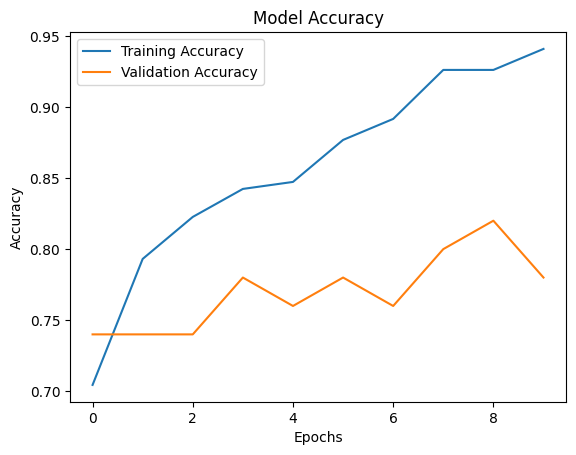

In [9]:
# Plot accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

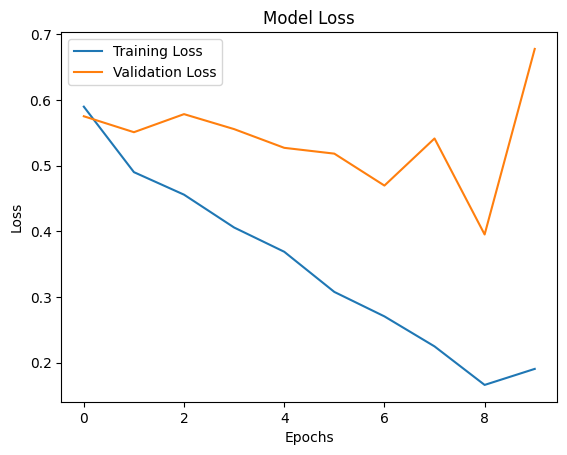

In [10]:
# Plot loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict classes
predictions = model.predict(val_data)
predicted_classes = (predictions > 0.5).astype(int)

# True classes
true_classes = val_data.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step
Confusion Matrix:
[[ 5 14]
 [ 5 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.26      0.34        19
           1       0.65      0.84      0.73        31

    accuracy                           0.62        50
   macro avg       0.57      0.55      0.54        50
weighted avg       0.59      0.62      0.59        50



In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze pretrained layers
base_model.trainable = False

# Create model
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

# Compile model
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Show model summary
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Train MobileNetV2 model
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 756ms/step - accuracy: 0.4631 - loss: 0.8454 - val_accuracy: 0.6200 - val_loss: 0.6942
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 569ms/step - accuracy: 0.6108 - loss: 0.6860 - val_accuracy: 0.6600 - val_loss: 0.6015
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 859ms/step - accuracy: 0.6798 - loss: 0.5692 - val_accuracy: 0.7600 - val_loss: 0.5309
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 666ms/step - accuracy: 0.7734 - loss: 0.5188 - val_accuracy: 0.7400 - val_loss: 0.4785
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 466ms/step - accuracy: 0.7833 - loss: 0.4656 - val_accuracy: 0.7800 - val_loss: 0.4599
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 776ms/step - accuracy: 0.8276 - loss: 0.4220 - val_accuracy: 0.7600 - val_loss: 0.4275
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 882ms/step - accuracy: 0.8670 - loss: 0.3908 - val_accuracy: 0.8200 - val_loss: 0.4134
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 0.8522 - loss: 0.3679 - val_accuracy: 0.7800 - val_loss

In [14]:
# Evaluate MobileNetV2 model
mobile_loss, mobile_accuracy = mobilenet_model.evaluate(val_data)

print("MobileNetV2 Validation Loss:", mobile_loss)
print("MobileNetV2 Validation Accuracy:", mobile_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.8200 - loss: 0.3913
MobileNetV2 Validation Loss: 0.39129889011383057
MobileNetV2 Validation Accuracy: 0.8199999928474426


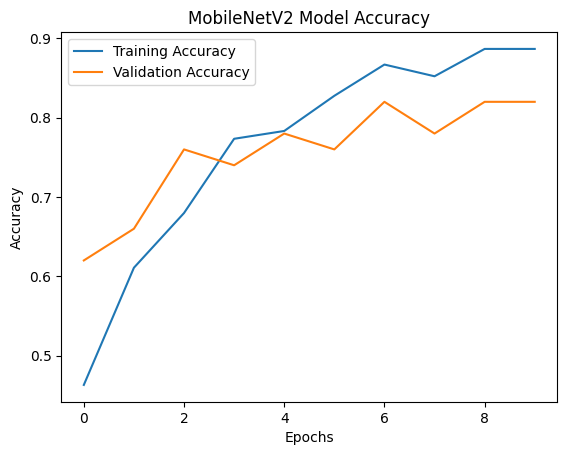

In [15]:
# Plot MobileNetV2 accuracy graph
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

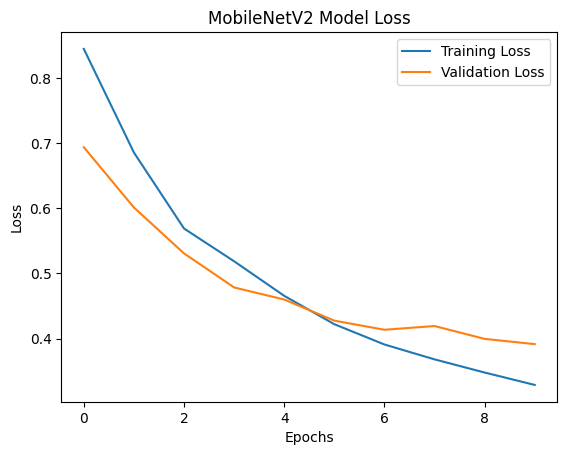

In [16]:
# Plot MobileNetV2 loss graph
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()